# Intro

## Importing Libraries

In [4]:
! pip install uszipcode

import pandas as pd
import json
import random
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import math
import numpy as np
import re
import string
import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from copy import deepcopy
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
import json
import geopandas as gpd
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import numpy as np


def capitalize_sent(sent):
  return ' '.join([word.capitalize() for word in sent.split()])

import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

## Download Data

In [30]:
! gdown "https://drive.google.com/drive/folders/19TTmyx0gCPJx9iNaySs7v8arvunhE68k?usp=drive_link" --folder

Retrieving folder contents
Processing file 195Z4gho36ircKmlP7noa3Db_3r1P1Mtq Chicago_weather_cleaned.csv
Processing file 1SHUquk8AorNzSYJ6jE5XasQMuxJNKkau community_areas.json
Processing file 1c_lSvzLU1EEeWLjhnCecPWNs4ACPtOaX crime_dataset.csv
Processing file 11NR0x_30XuNkWg1YhurLqMZUKNwVXdPW divvy_dataset.csv
Processing file 1G8m0XCJznTT4vxGOdJPkajrleziNAsTF event_dataset.csv
Processing file 1B6-KMMxG7PhTnXBRjEUxpK-_T4mwKEN2 parks_reviews.json
Processing file 1UdtCixCRiAbh7EhI4nlY9UTSKNA7yh_3 train_data.csv
Processing file 1WTm9wPjviEQbyYcr-7aXKwdi-XJHj5Z9 train_dataset.csv
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=195Z4gho36ircKmlP7noa3Db_3r1P1Mtq
To: /content/CS418_CLEAN_DATA/Chicago_weather_cleaned.csv
100% 198k/198k [00:00<00:00, 4.31MB/s]
Downloading...
From: https://drive.google.com/uc?id=1SHUquk8AorNzSYJ6jE5XasQMuxJNKkau
To: /content/CS418_CLEAN_DATA/community_area

In [31]:
! mv CS418_CLEAN_DATA/* .

## GPT-5 Prompting and Data Expansion

In [32]:
# GPT-5 Prompt to get all crime words
'''

For each of the following crimes, give me a list of relevant words related to that crime.
The goal is that, given a crime, I will be able to search these words in a comment so that I know
whether that comment is talking about that crime. Your output should be a dictionary of lists such that each of
the following crimes is a key and its relevant words are values. Each related crime should be one word, not more.
Also consider other derivations; for instance, you should consider 'robbed' for 'robbery' as well:



['theft' 'battery' 'other offense' 'burglary' 'criminal trespass'
 'robbery' 'assault' 'deceptive practice' 'narcotics' 'criminal damage'
 'motor vehicle theft' 'prostitution' 'weapons violation' 'kidnapping'
 'offense involving children' 'sex offense'
 'interference with public officer' 'liquor law violation'
 'criminal sexual assault' 'public peace violation' 'stalking'
 'crim sexual assault' 'homicide' 'arson'
 'concealed carry license violation' 'gambling' 'obscenity'
 'public indecency' 'intimidation' 'human trafficking'
 'other narcotic violation' 'non-criminal' 'ritualism']

'''

"\n\nFor each of the following crimes, give me a list of relevant words related to that crime.\nThe goal is that, given a crime, I will be able to search these words in a comment so that I know\nwhether that comment is talking about that crime. Your output should be a dictionary of lists such that each of\nthe following crimes is a key and its relevant words are values. Each related crime should be one word, not more.\nAlso consider other derivations; for instance, you should consider 'robbed' for 'robbery' as well:\n\n\n\n['theft' 'battery' 'other offense' 'burglary' 'criminal trespass'\n 'robbery' 'assault' 'deceptive practice' 'narcotics' 'criminal damage'\n 'motor vehicle theft' 'prostitution' 'weapons violation' 'kidnapping'\n 'offense involving children' 'sex offense'\n 'interference with public officer' 'liquor law violation'\n 'criminal sexual assault' 'public peace violation' 'stalking'\n 'crim sexual assault' 'homicide' 'arson'\n 'concealed carry license violation' 'gambling'

In [33]:
all_crime_words_dict = {
"theft": ["theft", "steal", "stole", "stolen", "stealing", "thief", "larceny", "shoplifting", "shoplifter", "pickpocket", "pilfer", "pilfered", "snatch", "snatched", "swipe", "swiped", "loot", "looted", "boosted"],
"battery": ["battery", "battered", "beating", "beat", "beaten", "hit", "hits", "hitting", "punch", "punched", "slap", "slapped", "struck", "kick", "kicked", "kicking", "bruised", "choked", "choking"],
"other offense": ["offense", "violation", "infraction", "misconduct", "nuisance", "noncompliance", "breach", "contravention", "offending", "violate"],
"burglary": ["burglary", "burglar", "burglarized", "burglarize", "burgled", "housebreaking", "prowler", "prowling", "ransacked", "pried", "intruder", "forced"],
"criminal trespass": ["trespass", "trespassed", "trespassing", "intrusion", "intruder", "encroached", "encroaching", "unauthorized", "loitering", "squatting", "squatter"],
"robbery": ["robbery", "rob", "robbed", "robbing", "robber", "robbers", "mugging", "mugged", "mugger", "holdup", "heist", "stickup", "carjacking", "carjacked", "snatch", "snatched"],
"assault": ["assault", "assaulted", "assaulting", "attack", "attacked", "attacker", "threat", "threats", "threatened", "menace", "menacing", "struck", "hit", "punch"],
"deceptive practice": ["fraud", "frauds", "fraudulent", "scam", "scams", "scammed", "scamming", "swindle", "swindled", "cheat", "cheated", "cheating", "forgery", "forgeries", "counterfeit", "counterfeits", "phishing", "spoofing", "skimming", "impersonation", "embezzlement"],
"narcotics": ["narcotics", "drug", "drugs", "heroin", "cocaine", "crack", "opioid", "opioids", "fentanyl", "meth", "methamphetamine", "marijuana", "cannabis", "weed", "xanax", "oxycontin", "percocet", "ketamine", "ecstasy", "mdma", "lsd", "possession", "distribution", "dealing", "dealer", "trafficking", "stash"],
"criminal damage": ["vandalism", "vandalized", "graffiti", "damage", "damaged", "destroy", "destroyed", "destruction", "smash", "smashed", "deface", "defaced", "breakage", "sabotage", "tampering", "shattered", "keyed"],
"motor vehicle theft": ["stolen", "stole", "carjacking", "carjacked", "joyride", "joyriding", "hotwire", "hotwired", "boosted", "hijack", "hijacked"],
"prostitution": ["prostitution", "prostitute", "escorting", "escort", "solicitation", "solicit", "solicited", "pimp", "pimping", "john", "brothel", "madam", "sexwork"],
"weapons violation": ["gun", "guns", "firearm", "firearms", "pistol", "revolver", "rifle", "shotgun", "ammo", "ammunition", "magazine", "silencer", "switchblade", "knife", "blade", "brandishing", "discharge", "unlawful", "concealed", "possession"],
"kidnapping": ["kidnapping", "kidnap", "kidnapped", "abduct", "abducted", "abduction", "hostage", "snatched", "seized", "ransom"],
"offense involving children": ["endangerment", "neglect", "abuse", "abused", "abusive", "exploitation", "grooming", "molestation", "runaway", "custody", "truancy"],
"sex offense": ["molestation", "molested", "groping", "groped", "indecency", "lewdness", "exposure", "voyeurism", "voyeur", "peeping", "flashing", "fondling", "sodomy"],
"interference with public officer": ["obstruction", "obstructing", "resisting", "resisted", "impeding", "hindering", "interference", "fleeing", "eluding", "evading", "assaulting", "battering", "bribery", "tampering", "harassing"],
"liquor law violation": ["alcohol", "liquor", "beer", "wine", "spirits", "intoxicated", "drunk", "drinking", "bootlegging", "moonshine", "underage", "bar", "tavern"],
"criminal sexual assault": ["rape", "raped", "rapist", "raping", "forcible", "nonconsensual", "assault", "penetration", "coercion"],
"public peace violation": ["disorderly", "disturbance", "disturbing", "riot", "rioting", "affray", "brawl", "brawling", "loitering", "noise", "nuisance", "fighting", "uproar"],
"stalking": ["stalking", "stalker", "stalked", "harassing", "harassment", "following", "shadowing", "cyberstalking", "obsessed", "tailing"],
"crim sexual assault": ["rape", "raped", "rapist", "raping", "forcible", "nonconsensual", "assault", "penetration", "coercion"],
"homicide": ["homicide", "homicides", "homicidal", "murder", "murdered", "murderer", "killing", "killed", "slaying", "manslaughter"],
"arson": ["arson", "arsonist", "burning", "ignited", "torch", "torched", "incendiary", "fire"],
"concealed carry license violation": ["concealed", "carry", "license", "permit", "revoked", "revocation", "suspended", "violation", "unlicensed", "holster", "expired", "foid"],
"gambling": ["gambling", "gamble", "gambled", "bet", "bets", "betting", "wager", "wagers", "bookie", "bookmaking", "poker", "roulette", "blackjack", "casino", "lottery", "slots"],
"obscenity": ["obscenity", "obscene", "porn", "pornography", "smut", "indecent", "lewd", "vulgarity", "profane", "profanity"],
"public indecency": ["indecency", "indecent", "nudity", "nude", "exposure", "exposed", "lewdness", "flashing", "streaking", "urination", "urinated"],
"intimidation": ["intimidation", "intimidate", "threat", "threats", "threaten", "threatened", "coerce", "coercion", "menace", "menacing", "extort", "extortion", "blackmail"],
"human trafficking": ["trafficking", "trafficked", "smuggling", "smuggled", "exploitation", "exploited", "coercion", "forced", "bondage", "labor", "transport", "recruitment"],
"other narcotic violation": ["paraphernalia", "syringe", "syringes", "needle", "needles", "baggie", "contraband", "illicit", "possession", "pills", "capsules"],
"non-criminal": ["civil", "information", "found", "lost", "assist", "welfare", "accident", "medical"],
"ritualism": ["ritualism", "ritual", "occult", "ceremony", "ceremonial", "sacrifice", "sacrificial", "cult", "satanic", "witchcraft"]
}

reverse_subcrime_2_crime = {sub_crime: k for k, v in all_crime_words_dict.items() for sub_crime in v}
all_crime_words = [word for _, values in all_crime_words_dict.items() for word in values]
main_crimes_importances = {k: 0 for k, v in all_crime_words_dict.items()}

## Reading Data and Defining Functions

In [34]:
crime_dataset_path = 'drive/MyDrive/CS418_CLEAN_DATA/crime_dataset.csv'
divvy_dataset_path = 'drive/MyDrive/CS418_CLEAN_DATA/divvy_dataset.csv'
event_dataset_path = 'drive/MyDrive/CS418_CLEAN_DATA/event_dataset.csv'
station_dataset_path = 'drive/MyDrive/CS418_CLEAN_DATA/train_dataset.csv'
park_path = 'drive/MyDrive/CS418_CLEAN_DATA/parks_reviews.json'

crime_data = pd.read_csv(crime_dataset_path)
divvy_data = pd.read_csv(divvy_dataset_path)
event_data = pd.read_csv(event_dataset_path)
station_data = pd.read_csv(station_dataset_path)

with open(park_path, 'r') as f:
  parks = json.load(f)

In [35]:
crime_data

,date,block,primary type,description,location description,arrest,domestic,beat,district,community area,fbi code,x coordinate,y coordinate,year,latitude,longitude,location,neighborhood
0,2023-06-19 22:30:00,080xx s champlain ave,theft,$500 and under,apartment,False,False,631,6.0,44.0,06,1181960.0,1851868.0,2023,41.748750,-87.608803,"(41.748750204, -87.608802927)",chatham
1,2014-11-05 12:50:00,034xx n western ave,theft,retail theft,grocery food store,True,False,1921,19.0,5.0,06,1159771.0,1922681.0,2014,41.943553,-87.688162,"(41.943552694, -87.688162342)",north center
2,2024-04-21 21:00:00,035xx w flournoy st,battery,domestic battery simple,apartment,False,True,1133,11.0,27.0,08b,1152924.0,1896804.0,2024,41.872682,-87.714015,"(41.872682495, -87.714015459)",garfield park
3,2022-03-13 13:30:00,019xx w superior st,other offense,telephone threat,apartment,False,True,1221,12.0,24.0,08a,1163421.0,1905023.0,2022,41.895022,-87.675245,"(41.895021814, -87.675244755)",west town
4,2025-03-07 03:08:00,009xx n monticello ave,burglary,forcible entry,residence,True,False,1112,11.0,23.0,05,1151875.0,1906073.0,2025,41.898138,-87.717623,"(41.898138305, -87.717622673)",humboldt park
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2890429,2019-05-06 03:00:00,061xx n winthrop ave,criminal damage,to property,apartment,False,False,2433,24.0,77.0,14,1167753.0,1940728.0,2019,41.992906,-87.658302,"(41.992905649, -87.658301822)",edgewater
2890430,2015-03-02 09:30:00,044xx s drake ave,theft,$500 and under,residential yard (front/back),False,False,821,8.0,58.0,06,1153476.0,1874962.0,2015,41.812734,-87.712568,"(41.812734431, -87.712568416)",brighton park
2890431,2014-11-12 13:36:00,001xx s hamlin blvd,battery,domestic battery simple,residence,False,True,1122,11.0,26.0,08b,1151097.0,1898922.0,2014,41.878530,-87.720668,"(41.878530499, -87.720667749)",garfield park
2890432,2022-04-04 17:30:00,015xx e 74th pl,battery,domestic battery simple,apartment,False,True,324,3.0,43.0,08b,1187742.0,1855895.0,2022,41.759665,-87.587488,"(41.759665109, -87.587487921)",south shore


In [36]:
crime_neigh_stat = crime_data.groupby('neighborhood').size().reset_index(name='crime_count').sort_values(by='crime_count', ascending=False)
event_neigh_stat = event_data.groupby('neighborhood').size().reset_index(name='event_count').sort_values(by='event_count', ascending=False)

# we get neighborhoods with highest crimes and events
high_crime_neighs = crime_neigh_stat.iloc[:20]['neighborhood'].unique()
high_event_neighs = event_neigh_stat.iloc[:20]['neighborhood'].unique()

In [37]:
high_crime_neighs

array(['austin', 'englewood', 'garfield park', 'humboldt park',
       'south shore', 'north lawndale', 'loop', 'auburn gresham',
       'roseland', 'grand crossing', 'chatham', 'chicago lawn',
       'river north', 'lake view', 'belmont cragin', 'little village',
       'south chicago', 'new city', 'west loop', 'west pullman'],
      dtype=object)

## Preliminary Data Visualization

/tmp/ipython-input-1405775417.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


Text(0, 0.5, 'Crime Count')

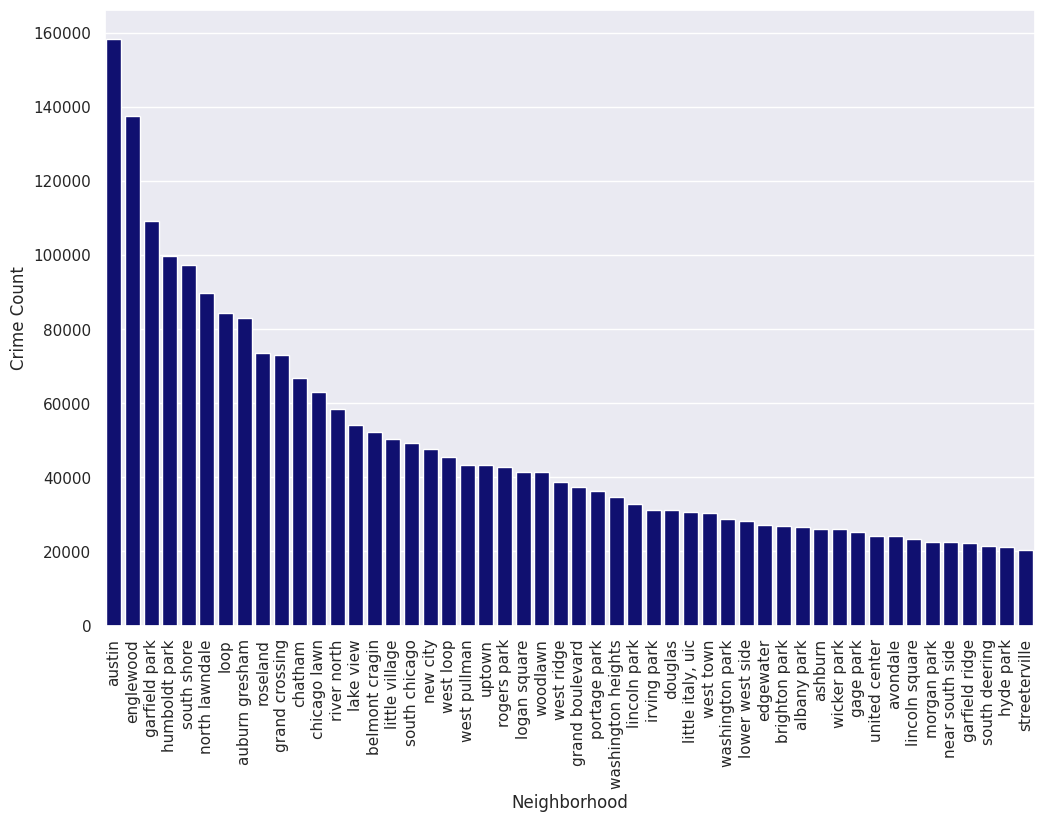

In [38]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.set(font_scale=1.)
ax = sns.barplot(x='neighborhood', y='crime_count', data=crime_neigh_stat.iloc[:50], ax=ax, color='navy')
_ = ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.set_xlabel('Neighborhood')
ax.set_ylabel('Crime Count')

In [39]:
crime_types = crime_data['primary type'].unique()
print(crime_types)

['theft' 'battery' 'other offense' 'burglary' 'criminal trespass'
 'robbery' 'assault' 'deceptive practice' 'narcotics' 'criminal damage'
 'motor vehicle theft' 'prostitution' 'weapons violation' 'kidnapping'
 'offense involving children' 'sex offense'
 'interference with public officer' 'liquor law violation'
 'criminal sexual assault' 'public peace violation' 'stalking'
 'crim sexual assault' 'homicide' 'arson'
 'concealed carry license violation' 'gambling' 'obscenity'
 'public indecency' 'intimidation' 'human trafficking'
 'other narcotic violation' 'non-criminal' 'ritualism']


In [40]:
# we prompted ChatGPT to spot the dangerous crimes from this list
dangerous_crimes = ['battery', 'robbery', 'assault', 'weapons violation', 'kidnapping', 'offense involving children', 'sex offense', 'criminal sexual assault', 'stalking', 'crim sexual assault', 'homicide', 'arson', 'intimidation']

In [41]:
high_crime_event_neighs = np.array(list(set(high_crime_neighs) & set(high_event_neighs)))

/tmp/ipython-input-171811204.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


Text(0, 0.5, 'Event Count')

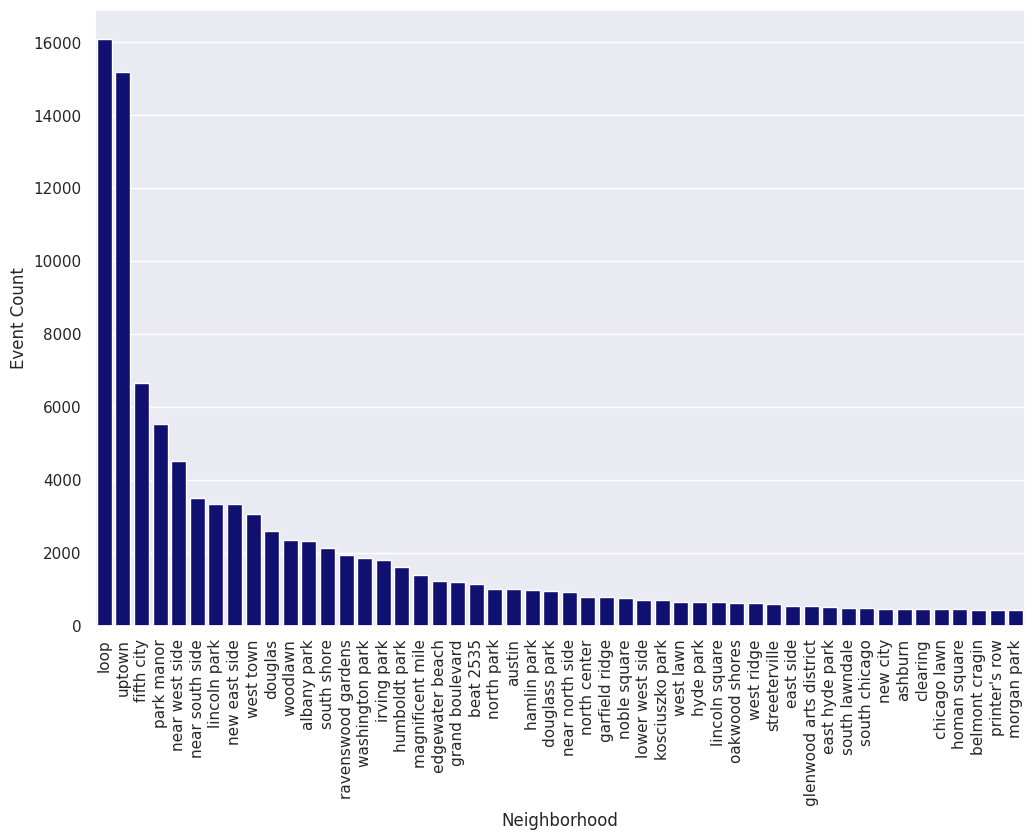

In [42]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.set(font_scale=1.)
ax = sns.barplot(x='neighborhood', y='event_count', data=event_neigh_stat.iloc[:50], ax=ax, color='navy')
_ = ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.set_xlabel('Neighborhood')
ax.set_ylabel('Event Count')

# Explore Crime and Event Data

In [43]:
crime_data['date'] = pd.to_datetime(crime_data['date'], errors='coerce')
event_data['reservation start date'] = pd.to_datetime(event_data['reservation start date'], errors='coerce')
event_data['reservation end date'] = pd.to_datetime(event_data['reservation end date'], errors='coerce')

In [44]:
high_crime_event_data = event_data[event_data['neighborhood'].isin(high_crime_neighs)]

In [45]:
high_crime_event_neighs

array(['south shore', 'humboldt park', 'loop'], dtype='<U13')

In [46]:
neigh_event_crime_mean = []
for neigh in high_crime_event_neighs:
  event_data_in_neigh = event_data[event_data['neighborhood'] == neigh]
  event_dates = event_data_in_neigh['reservation start date'].unique()

  crimes_in_event_dates = crime_data[(crime_data['date'].isin(event_dates)) & (crime_data['neighborhood'] == neigh)]
  crimes_in_non_event_dates = crime_data[(~crime_data['date'].isin(event_dates)) & (crime_data['neighborhood'] == neigh)]
  num_all_dates = (crime_data['date'].max() - crime_data['date'].min()).days
  num_event_dates = len(event_dates)
  num_non_event_dates = num_all_dates - num_event_dates

  if num_event_dates > 0:
    mean_crime_in_event_dates = len(crimes_in_event_dates) / num_event_dates
    mean_crime_in_non_event_dates = len(crimes_in_non_event_dates) / num_non_event_dates
    neigh_event_crime_mean.append([neigh, mean_crime_in_non_event_dates, mean_crime_in_event_dates])

In [47]:
df = pd.DataFrame(neigh_event_crime_mean, columns=['neighborhood', 'Non-Event Dates', 'Event Dates'])
df_melt = df.melt(id_vars='neighborhood', value_vars=['Non-Event Dates', 'Event Dates'],
                  var_name='kind', value_name='mean_crime')

In [48]:
df

,neighborhood,Non-Event Dates,Event Dates
0,south shore,36.254416,0.550453
1,humboldt park,30.409355,0.345455
2,loop,56.191919,0.290710


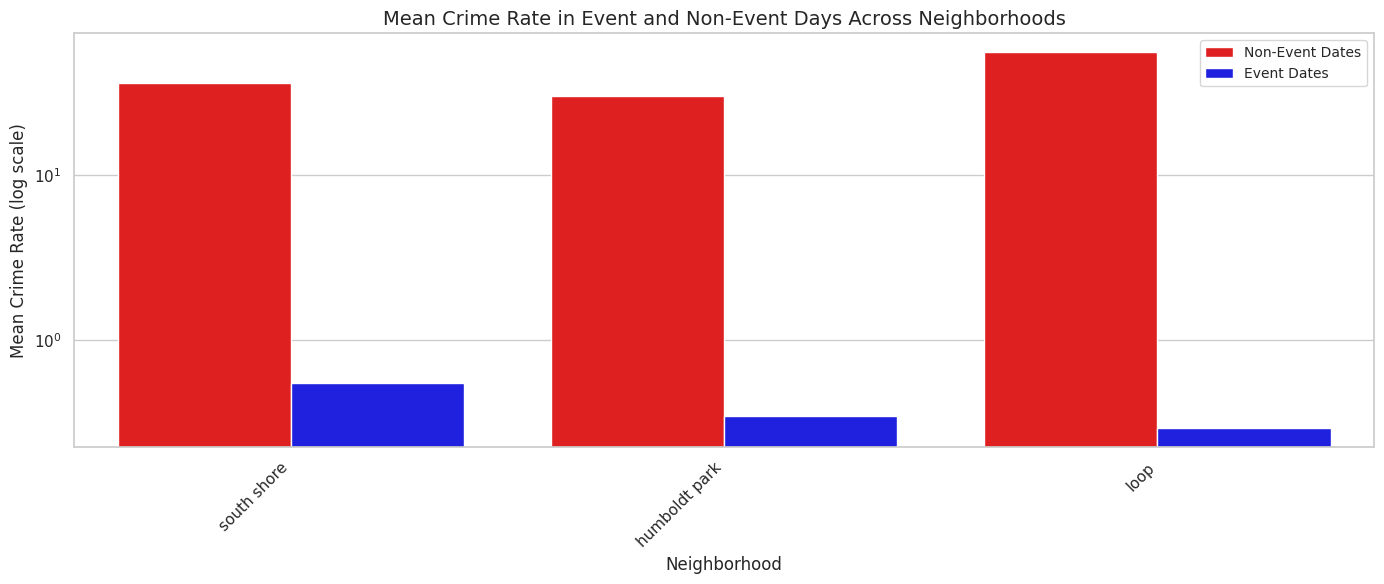

In [49]:
sns.set_theme(style="whitegrid")

# Plot grouped bars with custom colors
plt.figure(figsize=(14, 6))
ax = sns.barplot(x="neighborhood", y="mean_crime", hue="kind", data=df_melt, palette=['red', 'blue'])
ax.set_yscale('log')
plt.xticks(rotation=45, ha='right', fontsize=11)
ax.set_xlabel('Neighborhood', fontsize=12)
ax.set_ylabel('Mean Crime Rate (log scale)', fontsize=12)
ax.set_title('Mean Crime Rate in Event and Non-Event Days Across Neighborhoods', fontsize=14)
plt.legend(title='', fontsize=10)
plt.tight_layout()
plt.show()

/tmp/ipython-input-2727817484.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = axes[neigh_idx].set_xticklabels(labels=merged['primary type'], rotation=90, ha='right', fontsize=10)
/tmp/ipython-input-2727817484.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = axes[neigh_idx].set_xticklabels(labels=merged['primary type'], rotation=90, ha='right', fontsize=10)
/tmp/ipython-input-2727817484.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = axes[neigh_idx].set_xticklabels(labels=merged['primary type'], rotation=90, ha='right', fontsize=10)


Text(0.5, 1.05, 'Percentage of Each Crime In Three Neighborhoods During Event and Non-Event Dates')

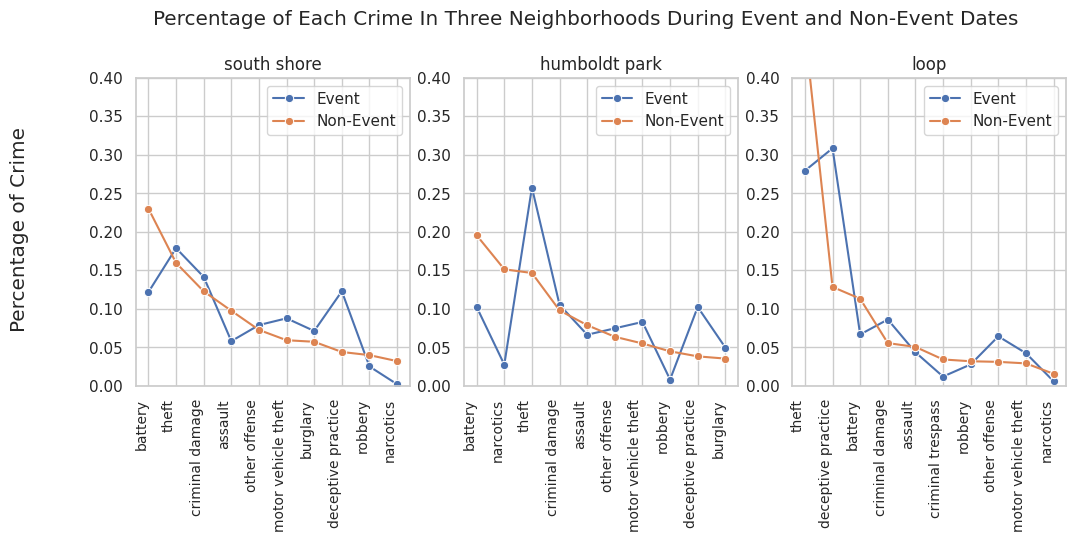

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for neigh_idx, neigh in enumerate(high_crime_event_neighs):

  event_data_in_neigh = event_data[event_data['neighborhood'] == neigh]
  event_dates = event_data_in_neigh['reservation start date'].unique()

  crimes_in_event_dates = crime_data[(crime_data['date'].isin(event_dates)) & (crime_data['neighborhood'] == neigh)]
  crimes_in_non_event_dates = crime_data[(~crime_data['date'].isin(event_dates)) & (crime_data['neighborhood'] == neigh)]

  event_data_in_neigh = event_data[event_data['neighborhood'] == neigh]
  event_dates = event_data_in_neigh['reservation start date'].unique()
  num_all_dates = (crime_data['date'].max() - crime_data['date'].min()).days
  num_event_dates = len(event_dates)
  num_non_event_dates = num_all_dates - num_event_dates


  typical_crimes_non_event_dates = crimes_in_non_event_dates.groupby('primary type').size().reset_index(name='num').sort_values(by='num', ascending=False)
  typical_crimes_event_dates = crimes_in_event_dates.groupby('primary type').size().reset_index(name='num').sort_values(by='num', ascending=False)

  typical_crimes_non_event_dates['crime_perc'] = typical_crimes_non_event_dates['num'] / typical_crimes_non_event_dates['num'].sum()
  typical_crimes_event_dates['crime_perc'] = typical_crimes_event_dates['num'] / typical_crimes_event_dates['num'].sum()

  all_types = list(set(typical_crimes_non_event_dates['primary type']) & set(typical_crimes_event_dates['primary type']))

  final_typical_crimes_event_dates = typical_crimes_event_dates[typical_crimes_event_dates['primary type'].isin(all_types)]
  final_typical_crimes_non_event_dates = typical_crimes_non_event_dates[typical_crimes_non_event_dates['primary type'].isin(all_types)]

  merged = (
      final_typical_crimes_event_dates[['primary type','crime_perc']]
      .merge(final_typical_crimes_non_event_dates[['primary type','crime_perc']], on='primary type', how='inner',
            suffixes=('_event', '_non_event'))
  )
  merged = merged.sort_values(by='crime_perc_non_event', ascending=False)

  sns.lineplot(x=merged['primary type'][:10],
             y=merged['crime_perc_event'][:10],
             marker='o',
             label='Event',
             ax=axes[neigh_idx])
  sns.lineplot(x=merged['primary type'][:10],
              y=merged['crime_perc_non_event'][:10],
              marker='o',
              label='Non-Event',
               ax=axes[neigh_idx])
  _ = axes[neigh_idx].set_xticklabels(labels=merged['primary type'], rotation=90, ha='right', fontsize=10)
  _ = axes[neigh_idx].set_title(neigh)
  axes[neigh_idx].set_xlabel('')
  axes[neigh_idx].set_ylabel('')
  axes[neigh_idx].set_ylim([0., .4])

fig.supylabel('Crime Type')
fig.supylabel('Percentage of Crime')
fig.suptitle('Percentage of Each Crime In Three Neighborhoods During Event and Non-Event Dates', y=1.05)

# Explore Park

## Build a classifier for ratings

In [51]:
lemmatizer=nltk.stem.wordnet.WordNetLemmatizer()
stopwords=nltk.corpus.stopwords.words('english')
# Convert part of speech tag from nltk.pos_tag to word net compatible format
def convert_pos_tag(pos):
  if pos[0] in posMapping.keys():
    return posMapping[pos[0]]
  else:
    return 'n'

def remove_puncs(text):
  new_text = ''
  for letter in text:
    if letter in string.punctuation:
      new_text += ' '
    else:
      new_text += letter
  return new_text

# Simple mapping based on first letter of return tag to make grading consistent
# Everything else will be considered noun 'n'
posMapping = {
# "First_Letter by nltk.pos_tag":"POS_for_lemmatizer"
    "N":'n',
    "V":'v',
    "J":'a',
    "R":'r'
}
# 14% credits
def process(text, lemmatizer=nltk.stem.wordnet.WordNetLemmatizer()):
    """ Normalizes case and handles punctuation
    Inputs:
        text: str: raw text
        lemmatizer: an instance of a class implementing the lemmatize() method
                    (the default argument is of type nltk.stem.wordnet.WordNetLemmatizer)
    Outputs:
        list(str): tokenized text
    """
    text = re.sub(r"\'", "", text)
    url_pattern = r'https?://(?:www\.)?[\w.-]+\.[\w]+(?:/[^\s]*)?'
    text = re.sub(url_pattern, ' ', text)
    text = re.sub('\s+', ' ', text)
    text = text.lower() # make it lowercase

    text = remove_puncs(text) # removing puncs
    tokens = nltk.word_tokenize(text) # tokenizing text
    # pos_tags = nltk.pos_tag(tokens)
    # tokenized_text = [lemmatizer.lemmatize(pos_tag[0], pos=convert_pos_tag(pos_tag[1])) for pos_tag in pos_tags]
    return ' '.join(tokens)

<>:41: SyntaxWarning: invalid escape sequence '\s'
<>:41: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-1766991049.py:41: SyntaxWarning: invalid escape sequence '\s'
  text = re.sub('\s+', ' ', text)


In [52]:
X, y = [], []
for park in parks:

  if park['reviews'] == {}:
    continue

  for review in park['reviews']['park_reviews']:
    if review['rating'] > 3:
      y.append(1)
      X.append(process(review['text']))
    elif review['rating'] < 3:
      y.append(0)
      X.append(process(review['text']))

In [53]:
vectorizer = TfidfVectorizer() # define vectorizer
# splitting to train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)
# training
X_train_tfidf = vectorizer.fit_transform(X_train)
clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train_tfidf, y_train)
# prediction
X_test_tfidf = vectorizer.transform(X_test)
preds = clf.predict(X_test_tfidf)
# print report
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.55      0.71      0.62        34
           1       0.98      0.95      0.97       438

    accuracy                           0.94       472
   macro avg       0.76      0.83      0.79       472
weighted avg       0.95      0.94      0.94       472



# Explore Train Data

In [54]:
lemmatizer=nltk.stem.wordnet.WordNetLemmatizer()
stopwords=nltk.corpus.stopwords.words('english')
# Convert part of speech tag from nltk.pos_tag to word net compatible format
def convert_pos_tag(pos):
  if pos[0] in posMapping.keys():
    return posMapping[pos[0]]
  else:
    return 'n'

def remove_puncs(text):
  new_text = ''
  for letter in text:
    if letter in string.punctuation:
      new_text += ' '
    else:
      new_text += letter
  return new_text

# Simple mapping based on first letter of return tag to make grading consistent
# Everything else will be considered noun 'n'
posMapping = {
# "First_Letter by nltk.pos_tag":"POS_for_lemmatizer"
    "N":'n',
    "V":'v',
    "J":'a',
    "R":'r'
}
# 14% credits
def process(text, lemmatizer=nltk.stem.wordnet.WordNetLemmatizer()):
    """ Normalizes case and handles punctuation
    Inputs:
        text: str: raw text
        lemmatizer: an instance of a class implementing the lemmatize() method
                    (the default argument is of type nltk.stem.wordnet.WordNetLemmatizer)
    Outputs:
        list(str): tokenized text
    """
    text = re.sub(r"\'", "", text)
    url_pattern = r'https?://(?:www\.)?[\w.-]+\.[\w]+(?:/[^\s]*)?'
    text = re.sub(url_pattern, ' ', text)
    text = re.sub('\s+', ' ', text)
    text = text.lower() # make it lowercase

    text = remove_puncs(text) # removing puncs
    tokens = nltk.word_tokenize(text) # tokenizing text
    # pos_tags = nltk.pos_tag(tokens)
    # tokenized_text = [lemmatizer.lemmatize(pos_tag[0], pos=convert_pos_tag(pos_tag[1])) for pos_tag in pos_tags]
    return ' '.join(tokens)

<>:41: SyntaxWarning: invalid escape sequence '\s'
<>:41: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-1766991049.py:41: SyntaxWarning: invalid escape sequence '\s'
  text = re.sub('\s+', ' ', text)


In [55]:
all_station_reviews = [json.loads(reviews) for reviews in station_data['reviews']]
X, y = [], []

for station_reviews in all_station_reviews:

  if station_reviews == {}:
    continue

  for review in station_reviews['station_reviews']:
    if review['rating'] > 3:
      y.append(1)
      X.append(process(review['text']))
    elif review['rating'] < 3:
      y.append(0)
      X.append(process(review['text']))

In [56]:
vectorizer = TfidfVectorizer() # define vectorizer
# splitting to train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)
# training
X_train_tfidf = vectorizer.fit_transform(X_train)
clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train_tfidf, y_train)
# prediction
X_test_tfidf = vectorizer.transform(X_test)
preds = clf.predict(X_test_tfidf)
# print report
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.61      0.61      0.61        28
           1       0.88      0.88      0.88        92

    accuracy                           0.82       120
   macro avg       0.74      0.74      0.74       120
weighted avg       0.82      0.82      0.82       120



In [57]:
neigh_station_crimes = {}

for _, station in station_data.iterrows():
  station_reviews = json.loads(station['reviews'])
  neighborhood = str(station['neighborhood'])
  if station_reviews == {} or neighborhood == 'nan':
    continue

  if neighborhood not in neigh_station_crimes.keys():
    neigh_station_crimes[neighborhood] = deepcopy(main_crimes_importances)

  reviews = station_reviews['station_reviews']
  reviews_text = [review['text'] for review in reviews]

  for review_text in reviews_text:

    coefs = clf.coef_[0]
    features = vectorizer.get_feature_names_out()
    X_review = vectorizer.transform([review_text])
    indices = X_review.indices
    values = X_review.data
    words = features[indices]
    # get word importances
    words_importance = values * coefs[indices]

    for word, word_importance in zip(words, words_importance):
      if word in all_crime_words and word_importance < 0:
        if word in reverse_subcrime_2_crime.keys():
          main_crime = reverse_subcrime_2_crime[word]
          neigh_station_crimes[neighborhood][main_crime] += abs(word_importance)


In [58]:
for neigh, crimes in neigh_station_crimes.items():
    for crime in list(crimes.keys()):
        if crimes[crime] == 0:
            del crimes[crime]

filtered_neigh_station_crimes = {k: v for k, v in neigh_station_crimes.items() if v != {}}

In [59]:
def shorten_labels(labels):
  labels = list(labels)
  new_labels = []
  for label in labels:
    if label == 'concealed carry license violation':
      label = 'license-violation'
    elif label == 'public peace violation':
      label = 'peace-violation'
    elif label == 'motor vehicle theft':
      label = 'vehicle-theft'
    new_labels.append(label)
  return new_labels

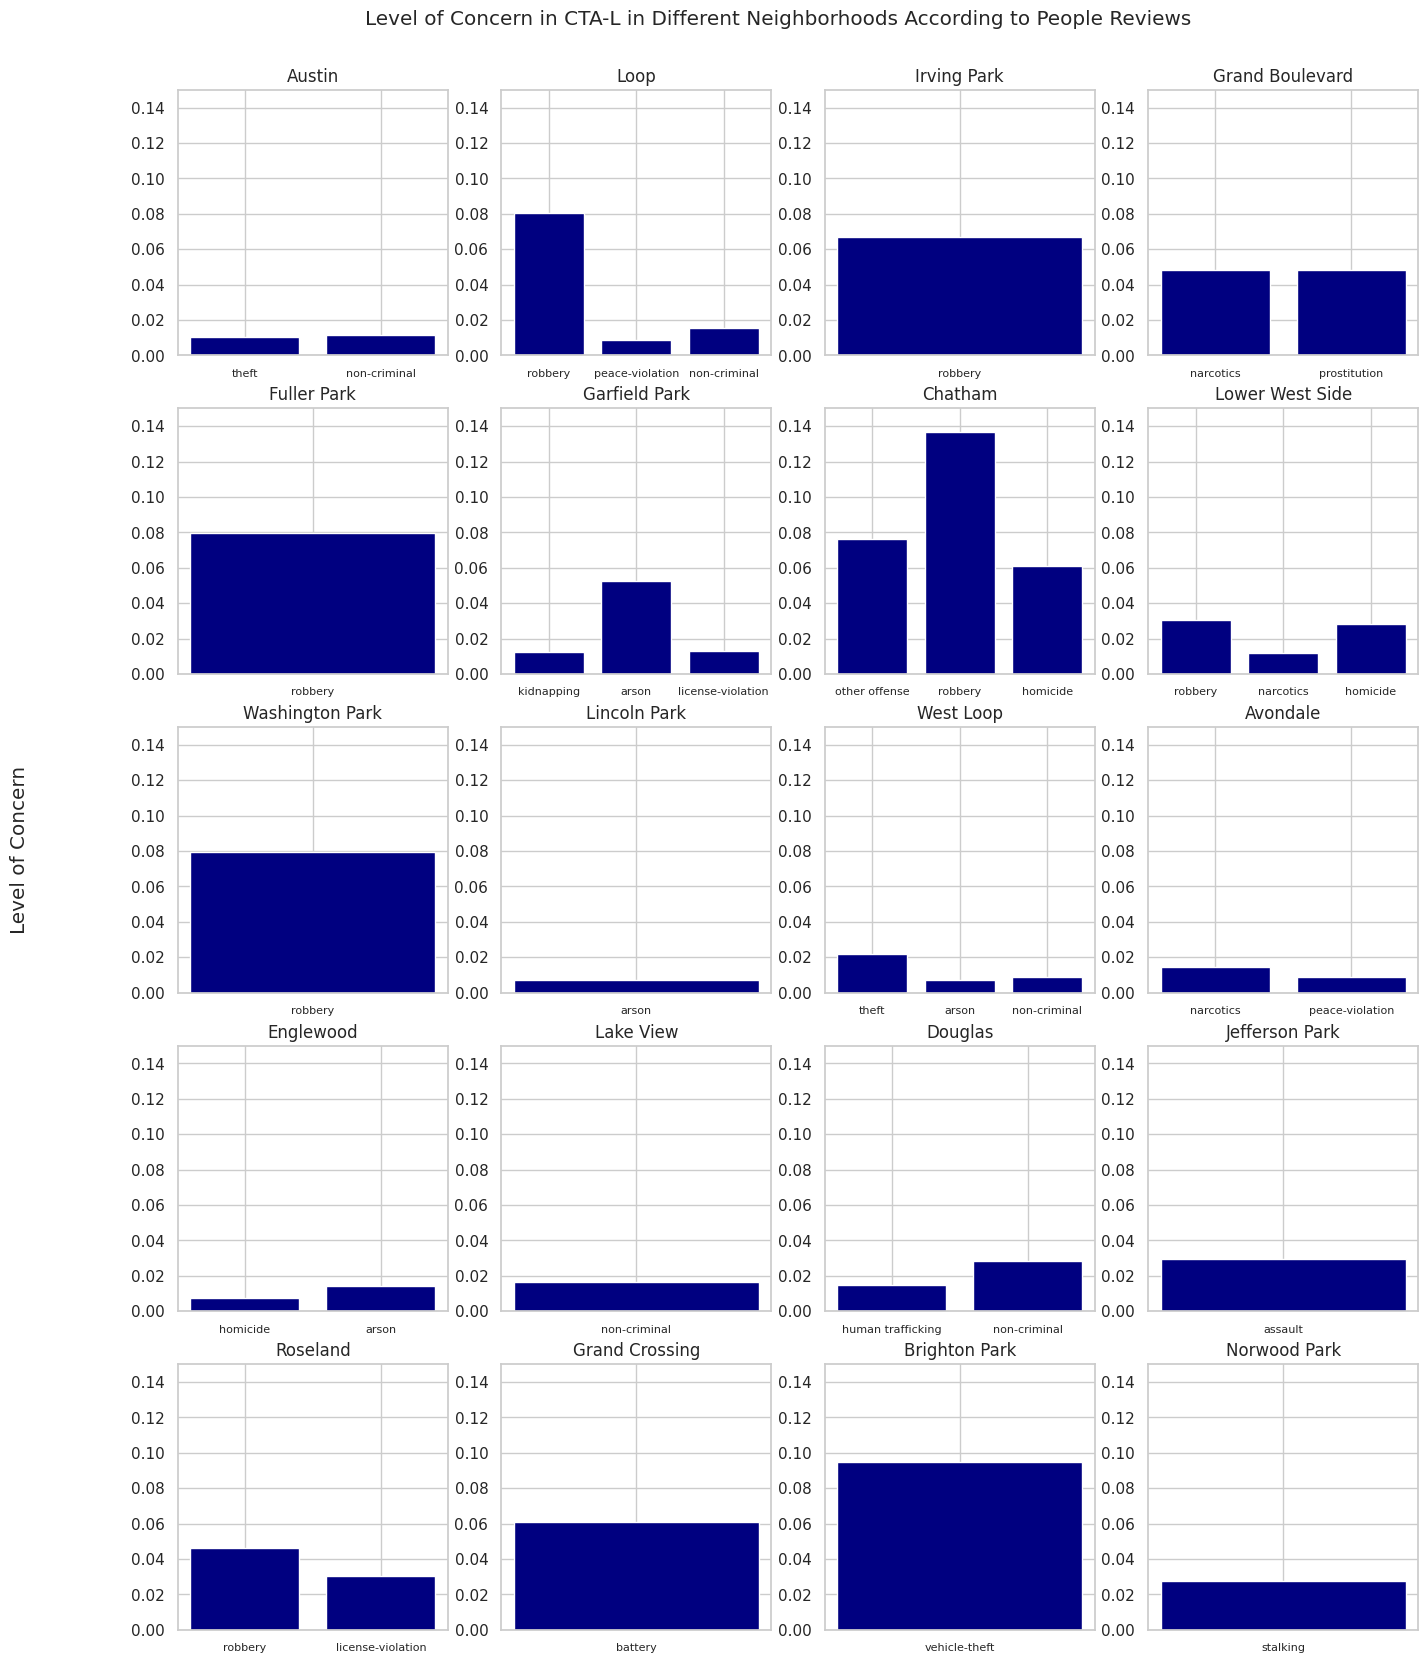

In [60]:
fig, axes = plt.subplots(5, 4, figsize=(16, 20))

for neigh_idx, (k, v) in enumerate(filtered_neigh_station_crimes.items()):
  i, j = neigh_idx // 4, neigh_idx % 4
  axes[i, j].bar(shorten_labels(v.keys()), v.values(), color='navy')
  axes[i, j].set_ylim([0, 0.15])
  axes[i, j].set_title(k)
  axes[i, j].tick_params(axis='x', labelsize=8)

_ = fig.supylabel('Level of Concern')
_ = plt.suptitle('Level of Concern in CTA-L in Different Neighborhoods According to People Reviews', y=.92)

# Clustering Neighborhoods based on Crime Similarity

## Compute Features

In [171]:
neighborhoods = np.array(list(crime_data['neighborhood'].unique()))
crime_types = np.array(list(crime_data['primary type'].unique()))

neighs_vectors = {}
for neigh in tqdm(neighborhoods):
  neighs_vectors[neigh] = []
  neigh_crime_types = crime_data[crime_data['neighborhood'] == neigh][['primary type']]
  neigh_all_crime_len = len(neigh_crime_types)

  for crime_type in crime_types:
    crime_type_len = len(neigh_crime_types[neigh_crime_types['primary type'] == crime_type])
    crime_type_ratio = crime_type_len / neigh_all_crime_len
    neighs_vectors[neigh].append(crime_type_ratio)

X = [v for k, v in neighs_vectors.items()]

100%|██████████| 98/98 [00:43<00:00,  2.23it/s]


## Kmeans

In [172]:
def draw_elbow(normalized_X, ks=[1, 2,3,4,5,6,7,8]):
  k_record, inertia_record = [], []
  for k in ks:
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(normalized_X)
    kmeans = KMeans(n_clusters=k, random_state=1000, n_init='auto')
    labels = kmeans.fit_predict(X_pca)

    k_record.append(k)
    inertia_record.append(kmeans.inertia_)
  plt.plot(k_record, inertia_record, marker='o')
  plt.xlabel('$k$')
  plt.ylabel('Inertia')
  plt.title('Finding the best $k$ for K-means using the Elbow method')
  plt.show()

In [173]:
scaler = StandardScaler()
normalized_X = scaler.fit_transform(X)

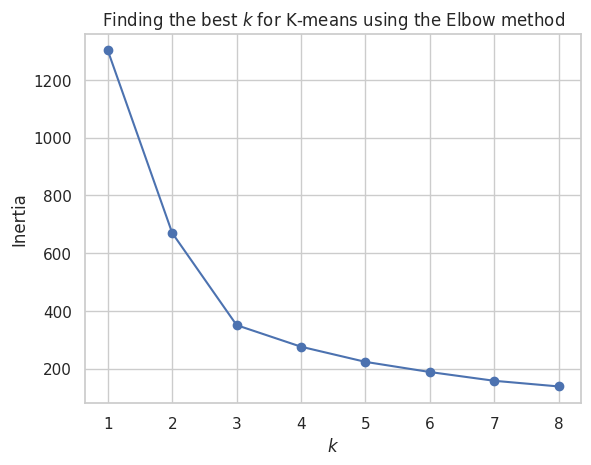

In [174]:
draw_elbow(normalized_X)

#### Best one is when k=3, so we pick that.

In [175]:
best_k = 3
pca = PCA(n_components=2)
X_pca = pca.fit_transform(normalized_X)
kmeans = KMeans(n_clusters=best_k, random_state=1000, n_init='auto')
labels = kmeans.fit_predict(X_pca)

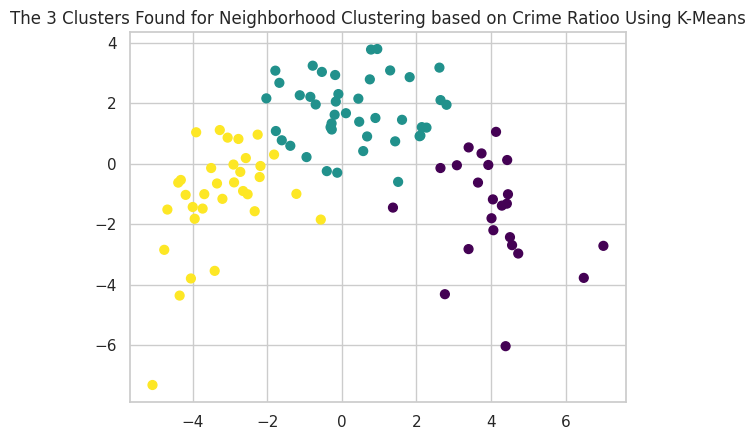

In [176]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=40)
_ = plt.title('The 3 Clusters Found for Neighborhood Clustering based on Crime Ratioo Using K-Means')
plt.show()

In [177]:
neighborhoods_groups = []
for label in range(3):
  neighborhoods_list = neighborhoods[labels == label]
  neighborhoods_list = [capitalize_sent(neigh) for neigh in neighborhoods_list]
  neighborhoods_groups.append(neighborhoods_list)

Available neighborhoods: ['Grand Boulevard', 'Printers Row', 'United Center', 'Sheffield & DePaul', 'Humboldt Park', 'Garfield Park', 'North Lawndale', 'Little Village', 'Armour Square', 'Avalon Park']
Neighborhood 'O'hare' in group 1 not found.
Neighborhood 'Sheffield & Depaul' in group 1 not found.
Neighborhood 'Little Italy, Uic' in group 2 not found.
Neighborhood 'Sauganash,forest Glen' in group 2 not found.
Invalid polygon for Norwood Park, skipping.
Invalid polygon for Streeterville, skipping.
Invalid polygon for O'Hare, skipping.
Invalid polygon for Lake View, skipping.


/tmp/ipython-input-2447709853.py:84: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1.0), prop={'size': 10})
/tmp/ipython-input-2447709853.py:84: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1.0), prop={'size': 10})


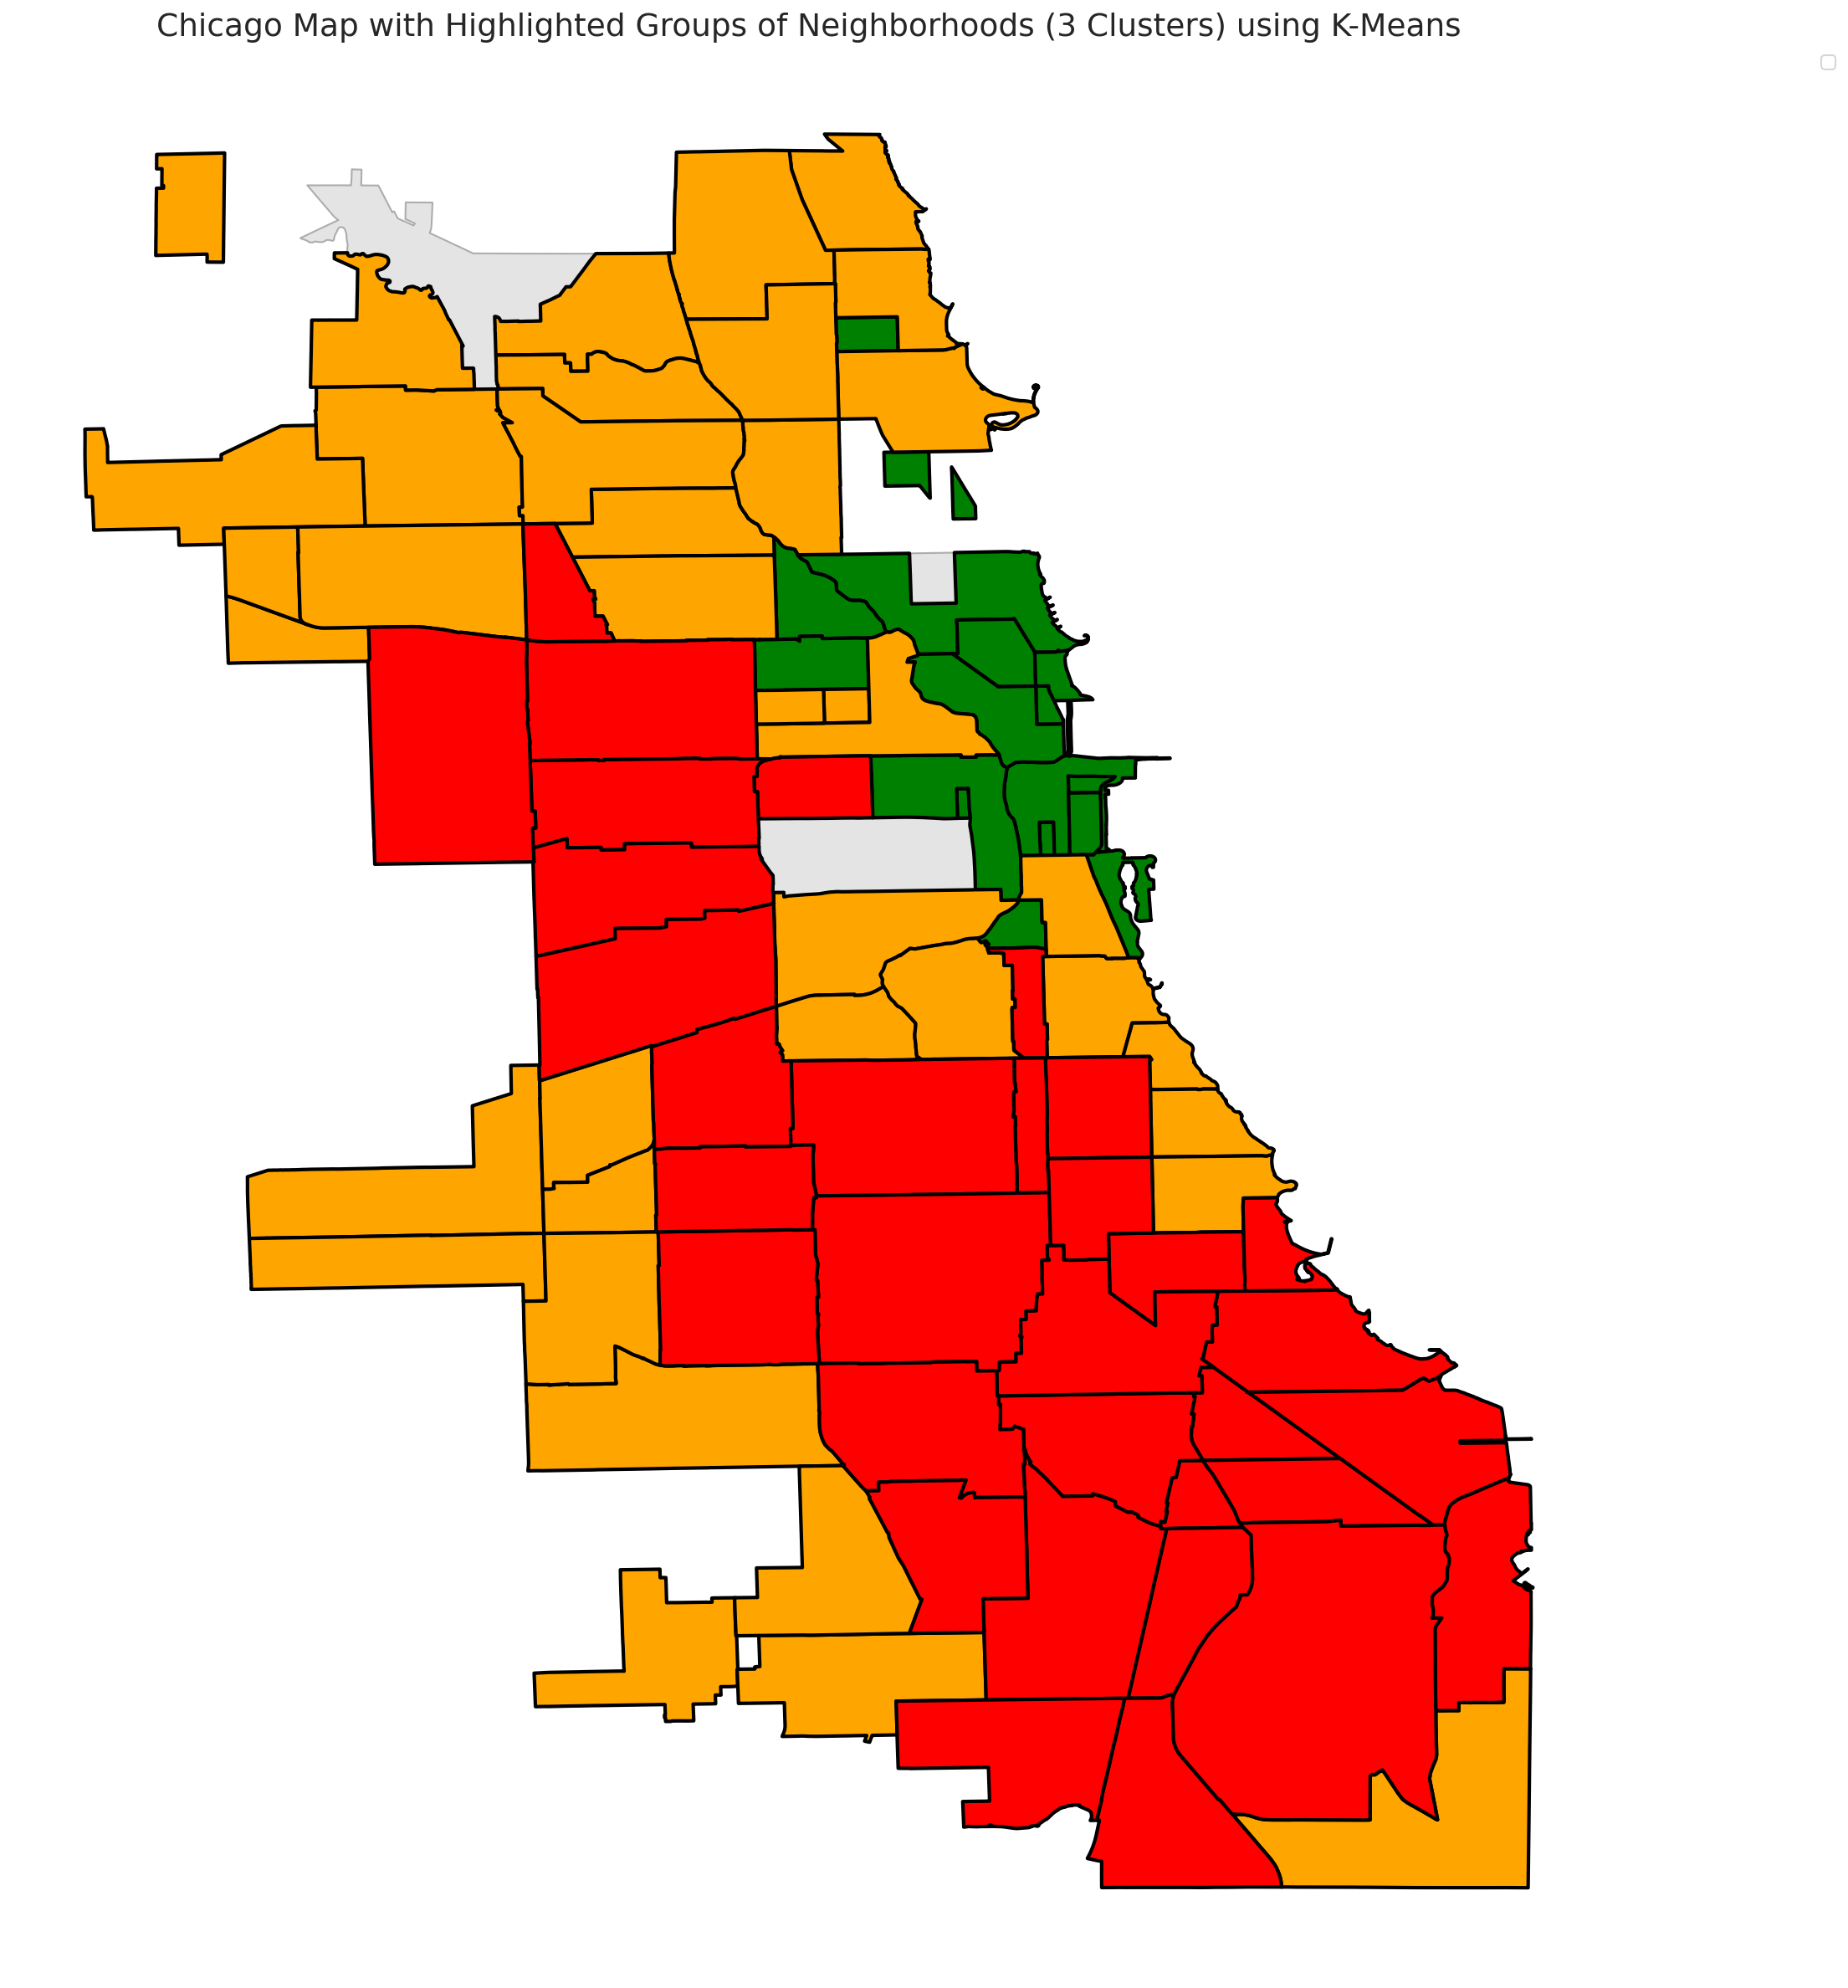

In [178]:
def draw_chicago_neighborhood(groups, colors, clustering_name, filename='community_areas.json'):


    with open(filename, 'r') as f:
        data = json.load(f)

    # print available neighborhoods
    available_neighborhoods = list(data.keys())
    print("Available neighborhoods:", available_neighborhoods[:10])

    # validate groups and collect all selected names
    all_selected_names = []
    valid_groups = []
    for group_id, group_names in enumerate(groups, 1):
        valid_in_group = []
        for name in group_names:
            if name not in data:
                print(f"Neighborhood '{name}' in group {group_id} not found.")
            else:
                valid_in_group.append(name)
                all_selected_names.append(name)
        if valid_in_group:
            valid_groups.append((group_id, valid_in_group))
        else:
            print(f"No valid neighborhoods in group {group_id}.")

    if not valid_groups:
        print("No matching neighborhoods found.")
        return

    # create geometries for all neighborhoods
    geometries = []
    for neigh in data:
        coords = data[neigh]

        if coords and coords[0] != coords[-1]:
            coords = coords + [coords[0]]
        try:
            polygon = Polygon(coords)
            if polygon.is_valid:
                geometries.append(polygon)
            else:
                print(f"Invalid polygon for {neigh}, skipping.")
                geometries.append(None)
        except Exception as e:
            print(f"Error creating polygon for {neigh}: {e}")
            geometries.append(None)

    # create GeoDataFrame
    gdf = gpd.GeoDataFrame({
        'neighborhood': list(data.keys()),
        'geometry': geometries
    })
    gdf = gdf[gdf['geometry'].notna()]  # Remove invalid geometries
    gdf.set_crs('EPSG:4326', inplace=True)  # WGS84 coordinate system

    # filter selected neighborhoods
    selected_gdf = gdf[gdf['neighborhood'].isin(all_selected_names)]

    # create the larger plot with higher DPI
    fig, ax = plt.subplots(1, 1, figsize=(16, 16), dpi=150)

    # plot all other neighborhoods in light gray
    other_areas = gdf[~gdf['neighborhood'].isin(all_selected_names)]
    other_areas.plot(ax=ax, color='lightgray', edgecolor='gray', alpha=0.6)


    # plot each group with its color
    for idx, (group_id, group_names) in enumerate(valid_groups):
        group_selected = selected_gdf[selected_gdf['neighborhood'].isin(group_names)]
        color = colors[idx]
        group_selected.plot(ax=ax, color=color, edgecolor='black', linewidth=2,
                           label=f'Group {group_id}: {len(group_names)} neighborhoods')

    # set equal aspect ratio for accurate map view
    ax.set_aspect('equal')

    # customize the map title
    title = f"Chicago Map with Highlighted Groups of Neighborhoods ({len(valid_groups)} Clusters) using {clustering_name}"
    ax.set_title(title, fontsize=18)
    ax.set_axis_off()

    # add legend
    ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1.0), prop={'size': 10})

    plt.tight_layout()
    plt.show()


draw_chicago_neighborhood(neighborhoods_groups, colors=['green', 'orange', 'red'], clustering_name='K-Means')

### Find Clusters Representatives' Crime Ratios & Comparison

In [179]:
kmeans_centers = kmeans.cluster_centers_
normalized_centers = pca.inverse_transform(kmeans_centers)
original_centers = scaler.inverse_transform(normalized_centers)

In [180]:
# Relatively Safer Areas
center = original_centers[0]
k = 10
sorted_indices = np.argsort(center)
top_k_indices = sorted_indices[-k:][::-1]
top_crimes = crime_types[top_k_indices]
center_crimes_ratio = center[top_k_indices]
for top_crime, crime_ratio in zip(top_crimes, center_crimes_ratio):
  print(f'crime: {top_crime}, ratio: {crime_ratio:.2f}')

crime: theft, ratio: 0.42
crime: battery, ratio: 0.12
crime: deceptive practice, ratio: 0.11
crime: criminal damage, ratio: 0.07
crime: assault, ratio: 0.05
crime: motor vehicle theft, ratio: 0.04
crime: other offense, ratio: 0.03
crime: criminal trespass, ratio: 0.03
crime: robbery, ratio: 0.03
crime: burglary, ratio: 0.03


In [181]:
center = original_centers[1]
k = 10
sorted_indices = np.argsort(center)
top_k_indices = sorted_indices[-k:][::-1]
top_crimes = crime_types[top_k_indices]
center_crimes_ratio = center[top_k_indices]
for top_crime, crime_ratio in zip(top_crimes, center_crimes_ratio):
  print(f'crime: {top_crime}, ratio: {crime_ratio:.2f}')

crime: theft, ratio: 0.26
crime: battery, ratio: 0.16
crime: criminal damage, ratio: 0.12
crime: deceptive practice, ratio: 0.09
crime: assault, ratio: 0.07
crime: other offense, ratio: 0.07
crime: motor vehicle theft, ratio: 0.06
crime: burglary, ratio: 0.05
crime: robbery, ratio: 0.03
crime: criminal trespass, ratio: 0.02


In [182]:
center = original_centers[2]
k = 10
sorted_indices = np.argsort(center)
top_k_indices = sorted_indices[-k:][::-1]
top_crimes = crime_types[top_k_indices]
center_crimes_ratio = center[top_k_indices]
for top_crime, crime_ratio in zip(top_crimes, center_crimes_ratio):
  print(f'crime: {top_crime}, ratio: {crime_ratio:.2f}')

crime: battery, ratio: 0.21
crime: theft, ratio: 0.16
crime: criminal damage, ratio: 0.12
crime: assault, ratio: 0.09
crime: other offense, ratio: 0.07
crime: motor vehicle theft, ratio: 0.06
crime: narcotics, ratio: 0.05
crime: deceptive practice, ratio: 0.05
crime: robbery, ratio: 0.04
crime: burglary, ratio: 0.04


In [183]:
all_top_crimes_in_order = set()

for center in original_centers:
  k = 10
  sorted_indices = np.argsort(center)
  top_k_indices = sorted_indices[-k:][::-1]
  top_crimes = crime_types[top_k_indices]
  for top_crime in top_crimes.tolist():
    all_top_crimes_in_order.add(top_crime)

all_top_crimes_in_order = list(all_top_crimes_in_order)


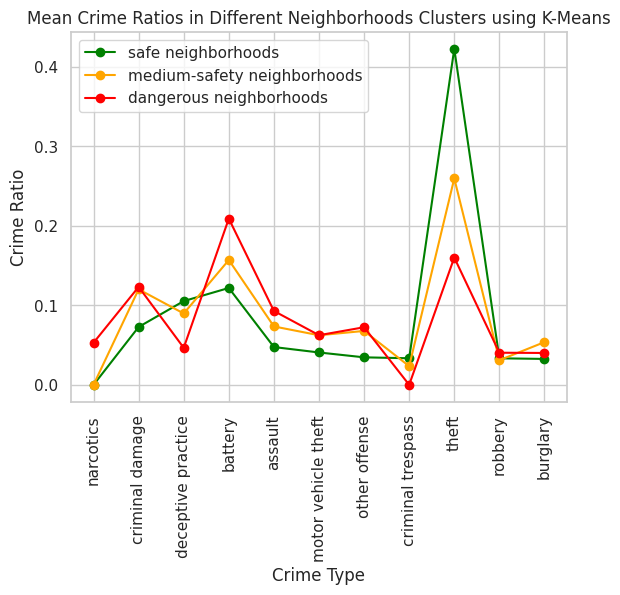

In [184]:
colors = ['green', 'orange', 'red']
labels = ['safe neighborhoods', 'medium-safety neighborhoods', 'dangerous neighborhoods']
for center_idx, center in enumerate(original_centers):
  k = 10
  sorted_indices = np.argsort(center)
  top_k_indices = sorted_indices[-k:][::-1]
  top_crimes = crime_types[top_k_indices]
  center_crimes_ratio = center[top_k_indices]
  center_crime_map = {
      crime: 0 for crime in all_top_crimes_in_order
  }
  for top_crime, crime_ratio in zip(top_crimes, center_crimes_ratio.tolist()):
    center_crime_map[top_crime] = crime_ratio
  plt.plot(center_crime_map.keys(), center_crime_map.values(), marker='o', color=colors[center_idx], label=labels[center_idx])
plt.xticks(rotation=90)
plt.xlabel('Crime Type')
plt.ylabel('Crime Ratio')
plt.title('Mean Crime Ratios in Different Neighborhoods Clusters using K-Means')
plt.legend()
plt.show()

## Agglomerative Clustering

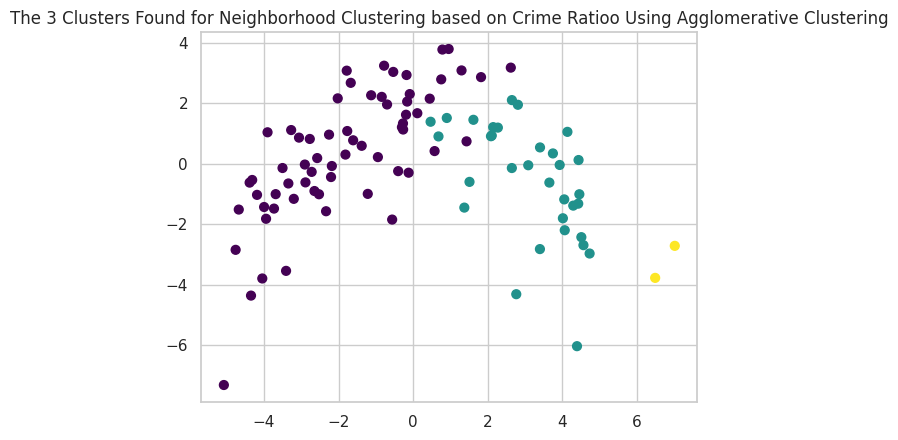

In [185]:
agg_clustering = AgglomerativeClustering(n_clusters=3).fit(X)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg_clustering.labels_, cmap='viridis', s=40)
_ = plt.title('The 3 Clusters Found for Neighborhood Clustering based on Crime Ratioo Using Agglomerative Clustering')
plt.show()

Available neighborhoods: ['Grand Boulevard', 'Printers Row', 'United Center', 'Sheffield & DePaul', 'Humboldt Park', 'Garfield Park', 'North Lawndale', 'Little Village', 'Armour Square', 'Avalon Park']
Neighborhood 'Little Italy, Uic' in group 1 not found.
Neighborhood 'Sauganash,forest Glen' in group 1 not found.
Neighborhood 'O'hare' in group 2 not found.
Neighborhood 'Sheffield & Depaul' in group 2 not found.
Invalid polygon for Norwood Park, skipping.
Invalid polygon for Streeterville, skipping.
Invalid polygon for O'Hare, skipping.
Invalid polygon for Lake View, skipping.


/tmp/ipython-input-2447709853.py:84: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1.0), prop={'size': 10})
/tmp/ipython-input-2447709853.py:84: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1.0), prop={'size': 10})


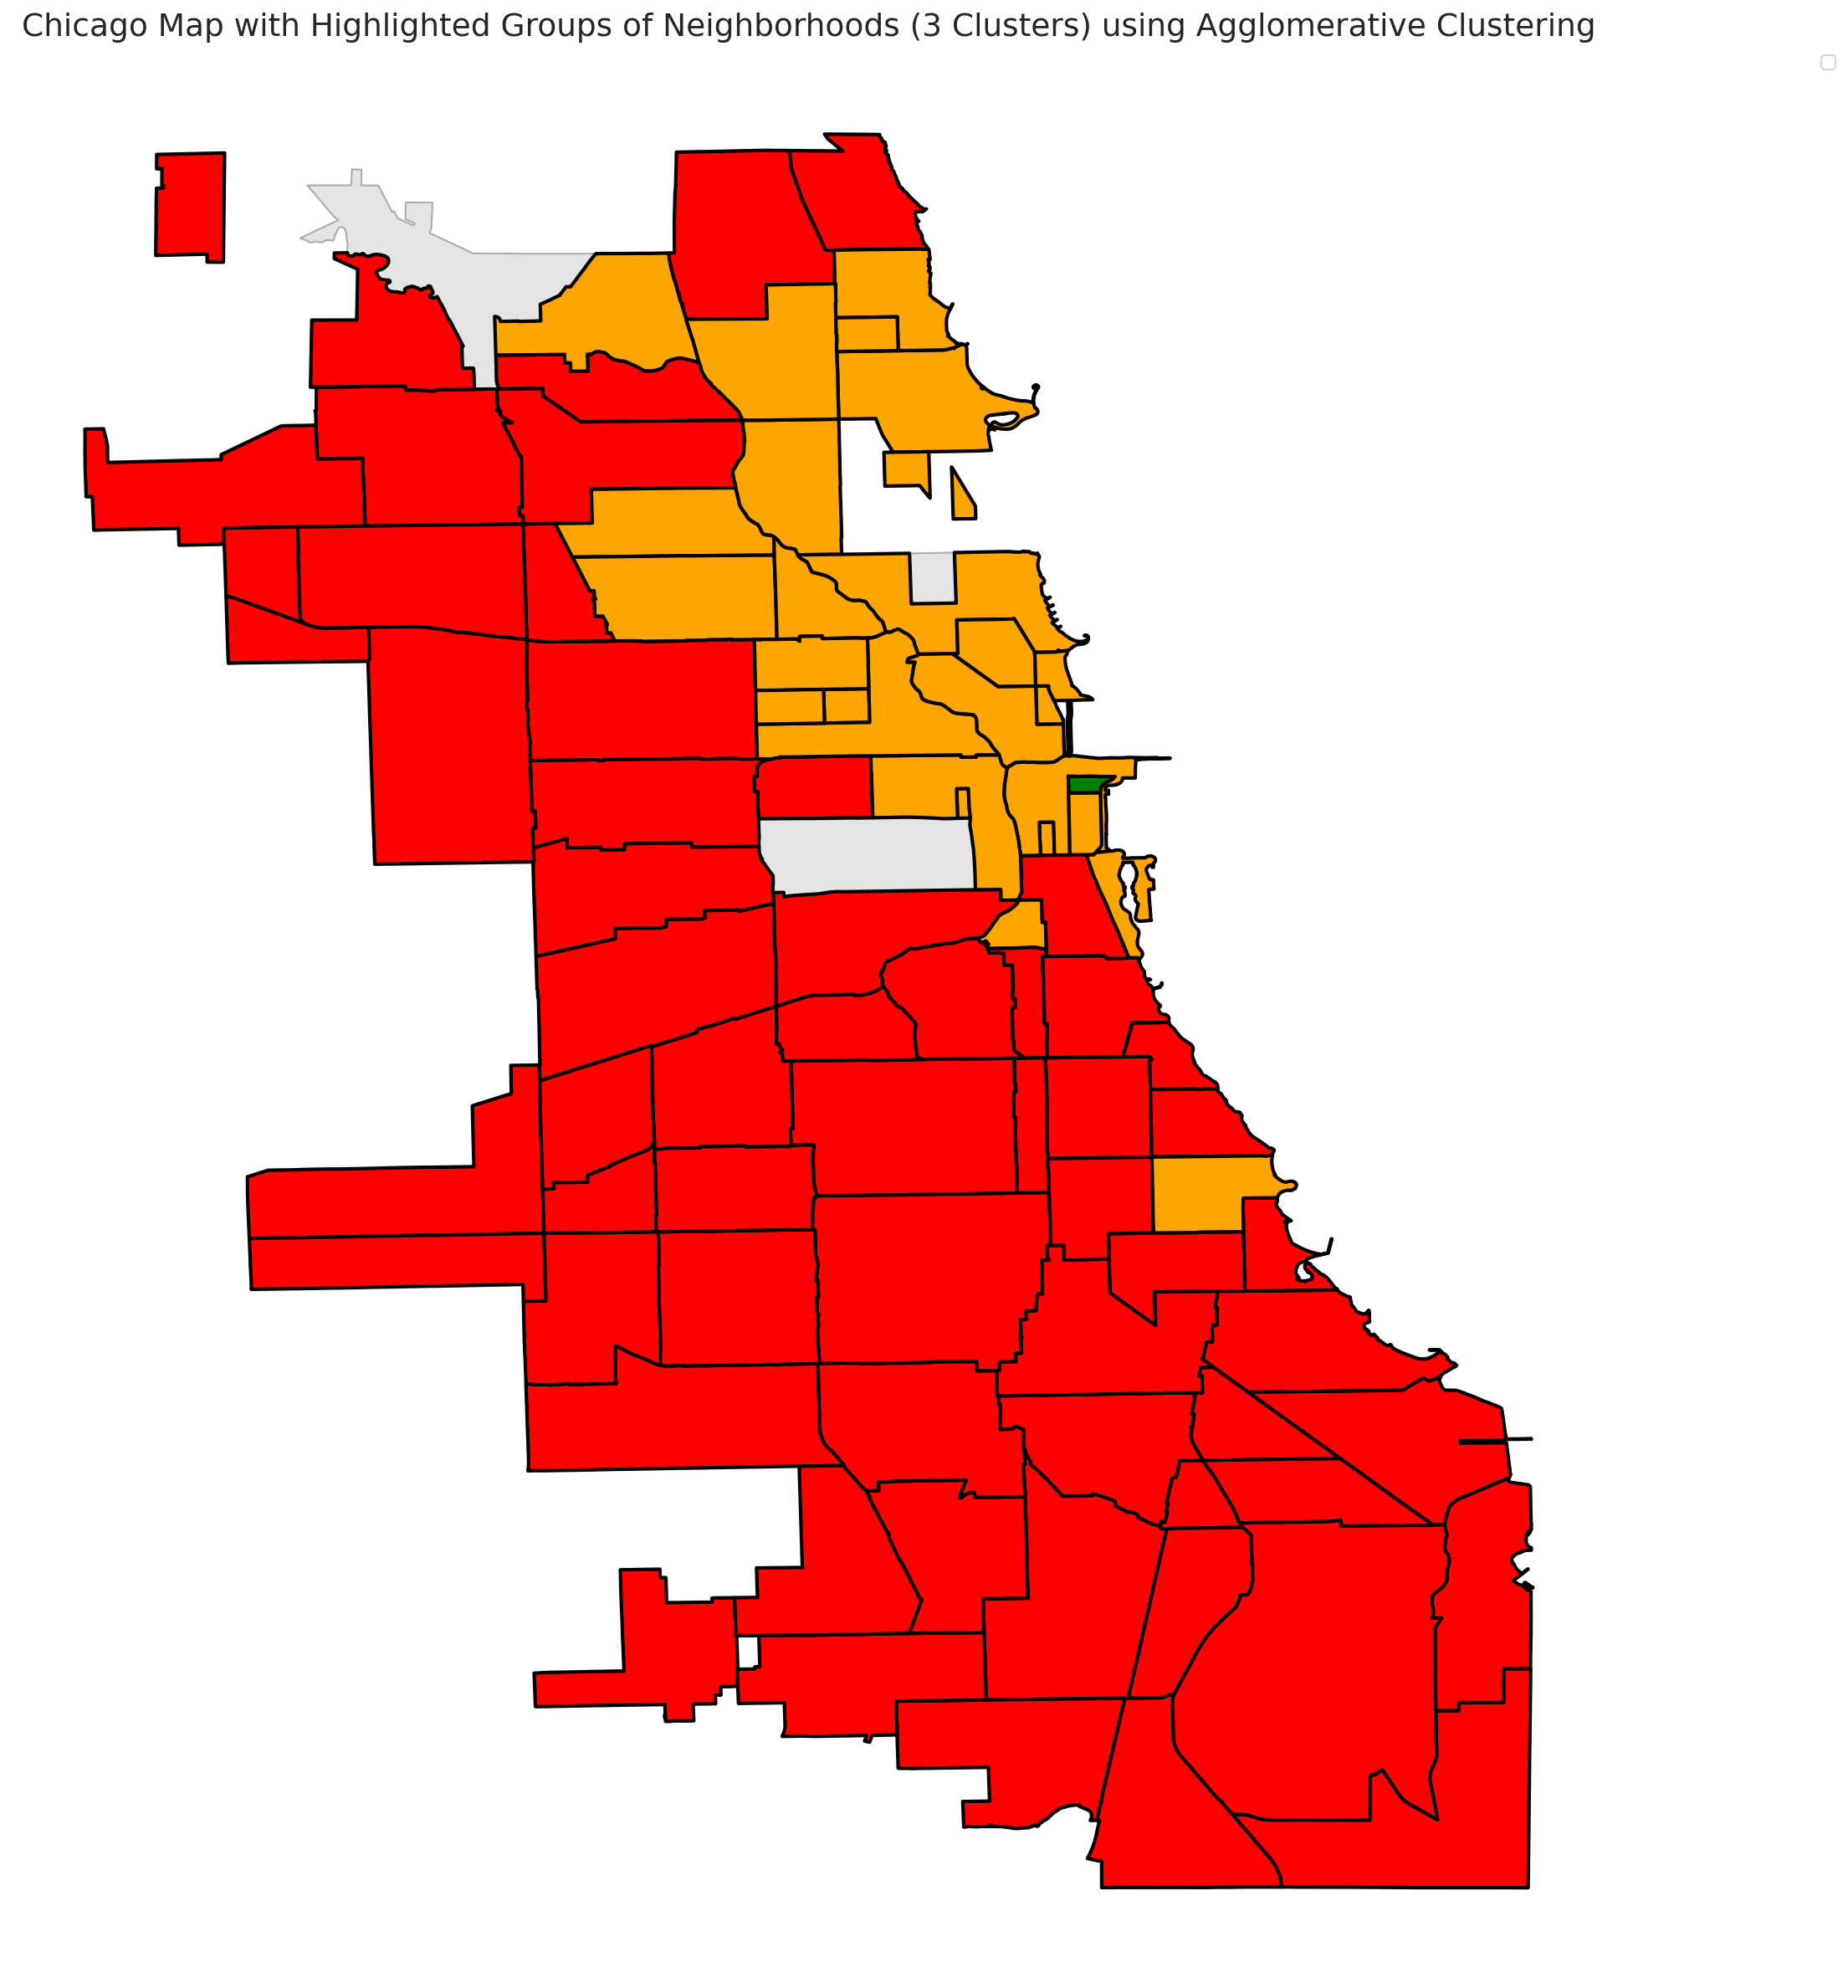

In [186]:
neighborhoods_groups = []
agg_centers = []
for label in range(3):
  neighborhoods_list = neighborhoods[agg_clustering.labels_ == label]
  neighborhoods_list = [capitalize_sent(neigh) for neigh in neighborhoods_list]
  neighborhoods_groups.append(neighborhoods_list)
  agg_centers.append(X_pca[agg_clustering.labels_ == label].mean(0))
draw_chicago_neighborhood(neighborhoods_groups, colors=['red', 'orange', 'green'], clustering_name='Agglomerative Clustering')

In [187]:
normalized_centers = pca.inverse_transform(agg_centers)
original_centers = scaler.inverse_transform(normalized_centers)

In [188]:
# Relatively Safer Areas
center = original_centers[0]
k = 10
sorted_indices = np.argsort(center)
top_k_indices = sorted_indices[-k:][::-1]
top_crimes = crime_types[top_k_indices]
center_crimes_ratio = center[top_k_indices]
for top_crime, crime_ratio in zip(top_crimes, center_crimes_ratio):
  print(f'crime: {top_crime}, ratio: {crime_ratio:.2f}')

crime: theft, ratio: 0.20
crime: battery, ratio: 0.19
crime: criminal damage, ratio: 0.12
crime: assault, ratio: 0.09
crime: other offense, ratio: 0.07
crime: deceptive practice, ratio: 0.07
crime: motor vehicle theft, ratio: 0.06
crime: burglary, ratio: 0.05
crime: robbery, ratio: 0.04
crime: narcotics, ratio: 0.03


In [189]:
center = original_centers[1]
k = 10
sorted_indices = np.argsort(center)
top_k_indices = sorted_indices[-k:][::-1]
top_crimes = crime_types[top_k_indices]
center_crimes_ratio = center[top_k_indices]
for top_crime, crime_ratio in zip(top_crimes, center_crimes_ratio):
  print(f'crime: {top_crime}, ratio: {crime_ratio:.2f}')

crime: theft, ratio: 0.38
crime: battery, ratio: 0.13
crime: deceptive practice, ratio: 0.10
crime: criminal damage, ratio: 0.09
crime: assault, ratio: 0.05
crime: motor vehicle theft, ratio: 0.05
crime: other offense, ratio: 0.04
crime: burglary, ratio: 0.04
crime: robbery, ratio: 0.03
crime: criminal trespass, ratio: 0.03


In [190]:
center = original_centers[2]
k = 10
sorted_indices = np.argsort(center)
top_k_indices = sorted_indices[-k:][::-1]
top_crimes = crime_types[top_k_indices]
center_crimes_ratio = center[top_k_indices]
for top_crime, crime_ratio in zip(top_crimes, center_crimes_ratio):
  print(f'crime: {top_crime}, ratio: {crime_ratio:.2f}')

crime: theft, ratio: 0.53
crime: deceptive practice, ratio: 0.12
crime: battery, ratio: 0.09
crime: criminal damage, ratio: 0.04
crime: criminal trespass, ratio: 0.04
crime: robbery, ratio: 0.03
crime: assault, ratio: 0.03
crime: motor vehicle theft, ratio: 0.03
crime: burglary, ratio: 0.02
crime: narcotics, ratio: 0.02


In [191]:
all_top_crimes_in_order = set()

for center in original_centers:
  k = 10
  sorted_indices = np.argsort(center)
  top_k_indices = sorted_indices[-k:][::-1]
  top_crimes = crime_types[top_k_indices]
  for top_crime in top_crimes.tolist():
    all_top_crimes_in_order.add(top_crime)

all_top_crimes_in_order = list(all_top_crimes_in_order)


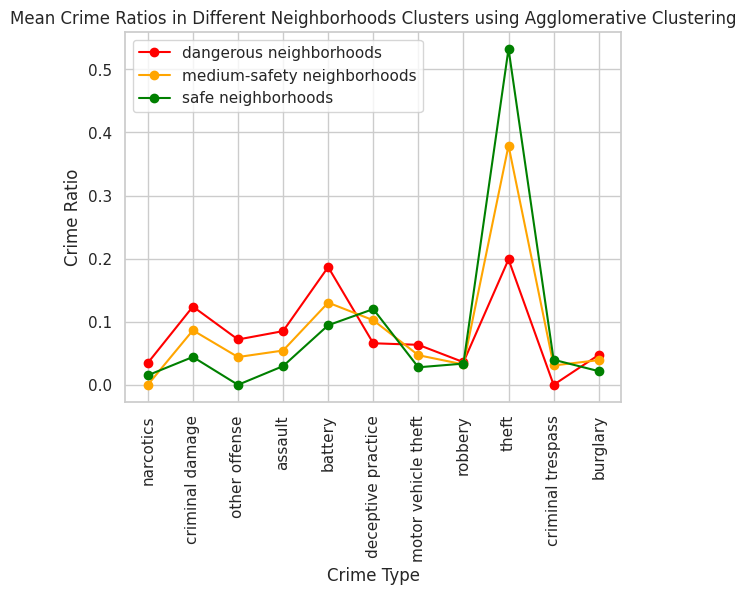

In [192]:
colors = ['red', 'orange', 'green']
labels = ['dangerous neighborhoods', 'medium-safety neighborhoods', 'safe neighborhoods']
for center_idx, center in enumerate(original_centers):
  k = 10
  sorted_indices = np.argsort(center)
  top_k_indices = sorted_indices[-k:][::-1]
  top_crimes = crime_types[top_k_indices]
  center_crimes_ratio = center[top_k_indices]
  center_crime_map = {
      crime: 0 for crime in all_top_crimes_in_order
  }
  for top_crime, crime_ratio in zip(top_crimes, center_crimes_ratio.tolist()):
    center_crime_map[top_crime] = crime_ratio
  plt.plot(center_crime_map.keys(), center_crime_map.values(), marker='o', color=colors[center_idx], label=labels[center_idx])
plt.xticks(rotation=90)
plt.xlabel('Crime Type')
plt.ylabel('Crime Ratio')
plt.title('Mean Crime Ratios in Different Neighborhoods Clusters using Agglomerative Clustering')
plt.legend()
plt.show()

## Analysis & Report'

### In this experiment, we want to cluster Chicago neighborhoods based on how similar they are in terms of different crimes. The goal is to find safer vs more dangerous neighborhoods in a coarse-grained manner. To this end:

**Compute Clusters**
+ We extract a feature vector for each neighborhood: we get the crime ratio for each crime (e.g. robbery: .2, homicide: .05, etc.) in that neighborhood as its feature vector.
+ We normalize feature vectors.
+ We use PCA with target dim=2 to lower the dimensionality.
+ We use Kmeans with different amounts of K's and using the Elbow method to find the best k using the inertia metric.
+ We get the best k as k=3.
+ We use K-Means and Agglomerative Clustering to cluster them based on 3 clusters.
  - Safe Neighborhoods
  - Medium-Saftey Neighborhoods
  - Dangerous Neighborhoods
+ We draw different clusters on Chicago map.

**Analysis**
+ For each cluster, we compute the center of cluster and map it back to the original vector space before applying PCA and normalization. We compare the ratio of different crimes in these three neighborhoods using their neighborhood center for each clustering method.

**Goal**
This way we get a good understanding of how crimes are distributed in different neighborhoods with different safety bars.

**Findings**
We observe that in safer neighborhoods, a less aggrevated crime like robbery is the most (areas like the Loop). On the other hand, in dangerous neighborhoods (e.g. the South and the West of Chicago), more aggressive crimes like battery and assualt (and even narcotics) are much higher compared to the other two clusters. deceptive practices are higher in safer neighborhoods, which is consistent with the fact that the green and orange neighborhoods are busier and usually host the most meetings; this is consistent with our findings with the crime-event analysis.